# 04 - Gözetimli Makine Öğrenmesi
## Uydu Telemetri Anomali Tespiti

Segment bazlı özellik matrisini kullanarak gözetimli anomali tespiti modellerini eğitmek.

### Modeller:
1. Random Forest
2. Support Vector Machine
3. XGBoost
4. MLP


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, sys
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

sys.path.insert(0, '..')
sys.path.insert(0, os.path.join('..', 'src'))
from src.models.supervised import SupervisedAnomalyDetector
from metrics import compute_metrics, metrics_table, BENCHMARK_METRICS

print('Kütüphaneler, Model Sınıfı ve metrik modülü yüklendi.')

I0000 00:00:1780778378.702663   44668 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780778378.732043   44668 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1780778379.425038   44668 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


please install torch first
please install torch first
please install torch first
Kütüphaneler, Model Sınıfı ve metrik modülü yüklendi.


---
## Bölüm 1: Veri Hazırlama


In [2]:
ESA_18_FEATURES = [
    'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks',
    'duration', 'len', 'gaps_squared', 'len_weighted',
    'var_div_duration', 'var_div_len',
    'smooth10_n_peaks', 'smooth20_n_peaks',
    'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var',
]
dataset = pd.read_csv('../data/raw/dataset.csv')
feature_cols = ESA_18_FEATURES

train_df = dataset[dataset['train'] == 1].copy()
test_df  = dataset[dataset['train'] == 0].copy()
print(f"Resmi split — T: {len(train_df)} ({train_df['anomaly'].sum()} anomali), "
      f"Ψ: {len(test_df)} ({test_df['anomaly'].sum()} anomali)")

X_train_full = train_df[feature_cols].fillna(0)
y_train_full = train_df['anomaly'].reset_index(drop=True)
X_test = test_df[feature_cols].fillna(0)
y_test = test_df['anomaly'].reset_index(drop=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_s, y_train_sm = smote.fit_resample(X_tr_s, y_tr)
y_train_sm = pd.Series(y_train_sm, name='anomaly')

print(f"Train (SMOTE'lu T): {X_train_s.shape}, Val: {X_val_s.shape}, Test Ψ: {X_test_s.shape}  (18 özellik)")

Resmi split — T: 1594 (321 anomali), Ψ: 529 (113 anomali)
Train (SMOTE'lu T): (2162, 18), Val: (240, 18), Test Ψ: (529, 18)  (18 özellik)


---
## Bölüm 2: Random Forest ve XGBoost


In [3]:
detector = SupervisedAnomalyDetector(random_state=42)
rf_model = detector.train_random_forest(X_train_s, y_train_sm, tune=False)
xgb_model = detector.train_xgboost(X_train_s, y_train_sm, X_val_s, y_val)


Random Forest eğitiliyor...


XGBoost eğitiliyor...


---
## Bölüm 3: SVM


In [4]:
svm_model = detector.train_svm(X_train_s, y_train_sm, kernel='rbf')


SVM (rbf kernel) eğitiliyor...


---
## Bölüm 4: MLP


MLP eğitiliyor...


Epoch 1/80


W0000 00:00:1780778384.564939   44668 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


 1/68 ━━━━━━━━━━━━━━━━━━━━ 59s 888ms/step - accuracy: 0.5938 - loss: 0.9263

38/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6969 - loss: 0.5733   

...

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9746 - loss: 0.0646 - val_accuracy: 0.9708 - val_loss: 0.1041


Epoch 50/80


 1/68 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9375 - loss: 0.1031

62/68 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - accuracy: 0.9742 - loss: 0.0629

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9750 - loss: 0.0632 - val_accuracy: 0.9542 - val_loss: 0.1094


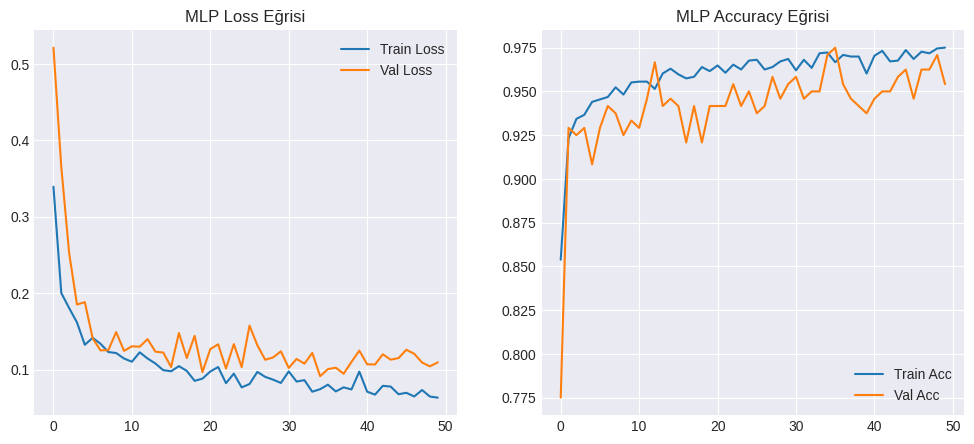

In [5]:
mlp_model, history = detector.train_mlp(X_train_s, y_train_sm.values, X_val_s, y_val.values, epochs=80, batch_size=32)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MLP Loss Eğrisi'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc'); plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('MLP Accuracy Eğrisi'); plt.legend()
plt.show()


---
## Bölüm 5: Değerlendirme


In [6]:
demo_metrics = {}
for name in ['RandomForest', 'XGBoost', 'SVM', 'MLP']:
    model = detector.models[name]
    if name == 'MLP':
        prob = model.predict(X_test_s, verbose=0).flatten()
    elif hasattr(model, 'predict_proba'):
        prob = model.predict_proba(X_test_s)[:, 1]
    else:
        prob = model.decision_function(X_test_s)
    pred = (prob >= 0.5).astype(int)
    demo_metrics[name] = compute_metrics(y_test.values, pred, prob)

results_df = metrics_table(demo_metrics, sort_by='AUC_PR')
print("Temsili gözetimli modeller — resmi Ψ (529 segment), AUC_PR sıralı:")
display(results_df[BENCHMARK_METRICS].style.background_gradient(cmap='Blues').format('{:.4f}'))

Temsili gözetimli modeller — resmi Ψ (529 segment), AUC_PR sıralı:


,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
MLP,0.9830,0.9483,0.9735,0.9607,0.9500,0.9936,0.9828
RandomForest,0.9565,0.8947,0.9027,0.8987,0.8710,0.9875,0.9644
XGBoost,0.9603,0.9107,0.9027,0.9067,0.8815,0.9818,0.9615
SVM,0.9698,0.9076,0.9558,0.9310,0.9122,0.9800,0.9301


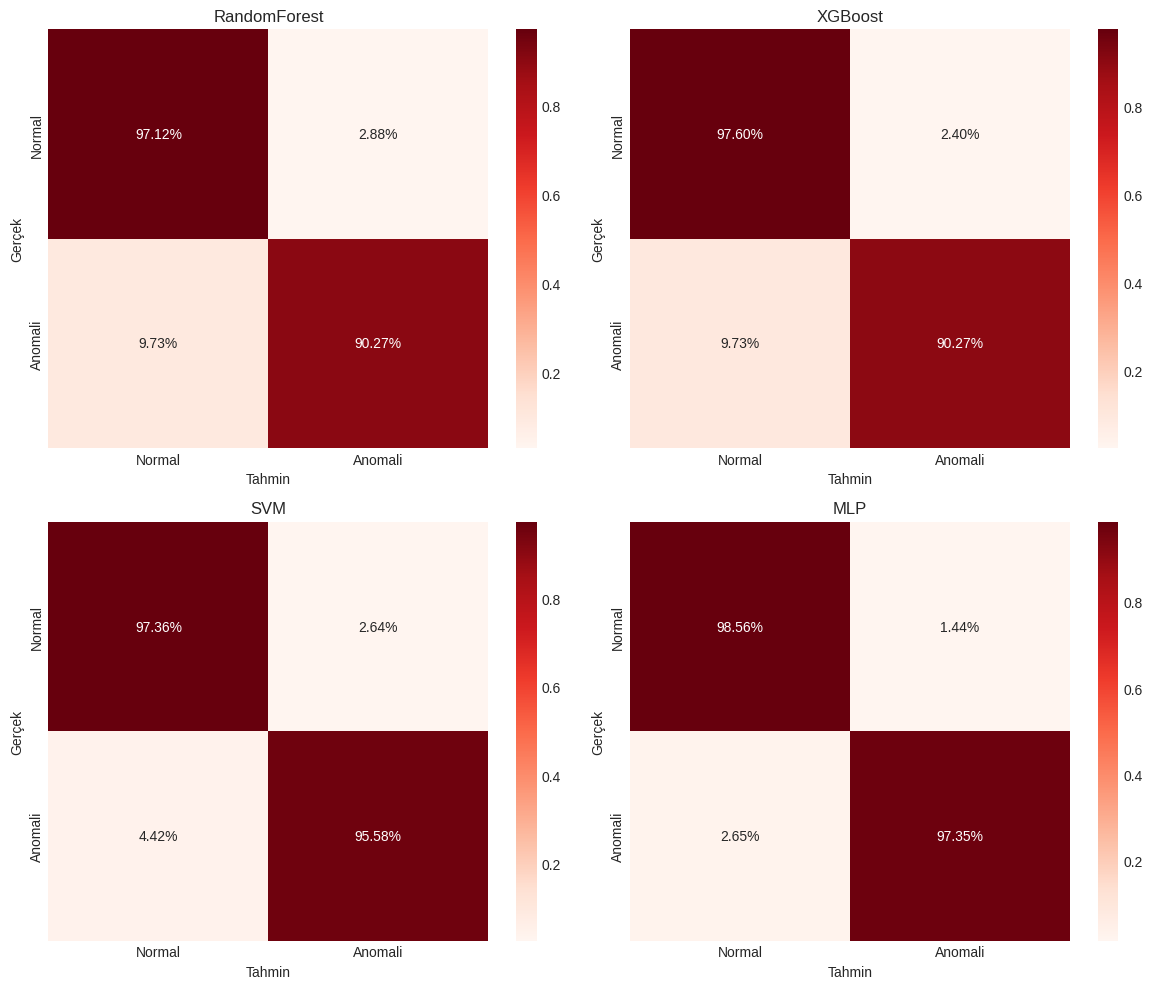

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10)); axes = axes.flatten()
for i, name in enumerate(detector.models.keys()):
    m = detector.models[name]
    yp = (m.predict(X_test_s, verbose=0)>=0.5).astype(int).flatten() if name=='MLP' else m.predict(X_test_s)
    cm = confusion_matrix(y_test, yp, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i], xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    axes[i].set_title(name); axes[i].set_xlabel('Tahmin'); axes[i].set_ylabel('Gerçek')
plt.tight_layout(); plt.show()


---
## Bölüm 6: ROC Eğrisi


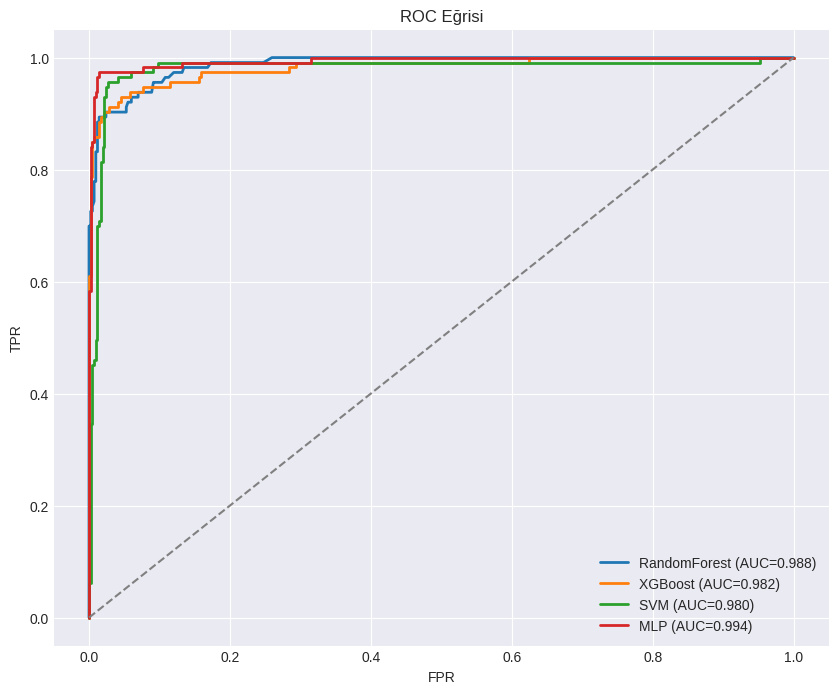

In [8]:
plt.figure(figsize=(10, 8))
for name, model in detector.models.items():
    yp = model.predict(X_test_s, verbose=0).flatten() if name=='MLP' else (model.predict_proba(X_test_s)[:,1] if hasattr(model,'predict_proba') else model.decision_function(X_test_s))
    fpr,tpr,_ = roc_curve(y_test, yp); ra = auc(fpr,tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Eğrisi'); plt.legend(loc='lower right')
plt.show()


---
## Bölüm 7: Kaydetme


In [9]:
print("Bu notebook gösterim amaçlıdır; kanonik artefaktlar train_all_models.py'den gelir.")

Bu notebook gösterim amaçlıdır; kanonik artefaktlar train_all_models.py'den gelir.


## 5. Gelişmiş Modeller\nBu bölümde projenin performansını maksimize etmek için eklenen LightGBM, CatBoost ve Ensemble modelleri bulunmaktadır.

## 2. Model Tanımlamaları ve Eğitim

In [11]:
print("Gelişmiş/genişletilmiş modeller train_all_models.py'de kanonik eğitiliyor (bkz. NB06).")

Gelişmiş/genişletilmiş modeller train_all_models.py'de kanonik eğitiliyor (bkz. NB06).


## 3. Performans Değerlendirme ve Modellerin Kaydedilmesi

In [12]:
print("Bkz. NB06 — kanonik karşılaştırma tablosu (final_comparison.json).")

Bkz. NB06 — kanonik karşılaştırma tablosu (final_comparison.json).


## 4. Feature Importance Karşılaştırması

In [13]:
print("Özellik önemi / yorumlanabilirlik için NB07 (SHAP analizi) kullanılır.")

Özellik önemi / yorumlanabilirlik için NB07 (SHAP analizi) kullanılır.


---
## 6. Genişletilmiş Modeller

Model havuzunu zenginleştirmek için 29 yeni gözetimli model eklenmiştir:

Klasik ML (14): Extra Trees, Gradient Boosting, HistGradientBoosting, AdaBoost, KNN, Logistic Regression, Decision Tree, Gaussian Naive Bayes, Voting Ensemble, LDA, QDA, Bagging, Ridge, SGD

Derin sıralı ve hibrit ağlar (15): LSTM, BiLSTM, GRU, BiGRU, 1D-CNN, CNN-LSTM, CNN-BiLSTM, CNN-GRU, Transformer, TCN, Attention-BiLSTM, FCN, ResNet-1D, InceptionTime, LSTM-FCN.

> Sıralı modeller tablo özelliklerini `(örnek, özellik, 1)` biçiminde 3B tensöre dönüştürerek işler; bu dönüşüm `SupervisedAnomalyDetector` içinde otomatik yapılır. FCN, ResNet-1D, InceptionTime ve LSTM-FCN, UCR benchmark'ında öne çıkan SOTA zaman serisi sınıflandırma mimarileridir. Tüm modeller Bölüm 1'deki aynı ölçeklenmiş (`X_*_s`) ve SMOTE ile dengelenmiş eğitim verisini kullanır.

In [14]:
print("14 klasik ML modeli train_all_models.py'de kanonik eğitiliyor (bkz. final_comparison.json).")

14 klasik ML modeli train_all_models.py'de kanonik eğitiliyor (bkz. final_comparison.json).


In [15]:
print("15 derin model train_all_models.py'de kanonik eğitiliyor; resmi Ψ sonuçları NB06'da.")

15 derin model train_all_models.py'de kanonik eğitiliyor; resmi Ψ sonuçları NB06'da.
